<a href="https://colab.research.google.com/github/mbroor/eeg-motor-imagery-bci/blob/main/01_motor_imagery_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mne --quiet
import mne
print(mne.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
1.12.1


In [4]:
mne.set_log_level("WARNING")

In [5]:
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject,runs)
raws = [read_raw_edf(f,preload = True) for f in files]

raw = concatenate_raws (raws)
print(raw.info)

Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


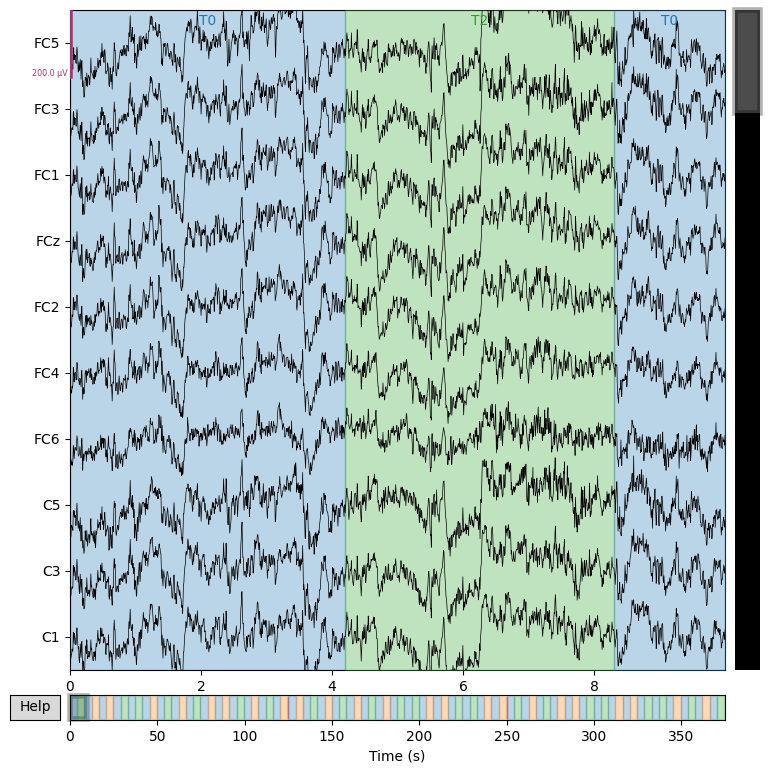

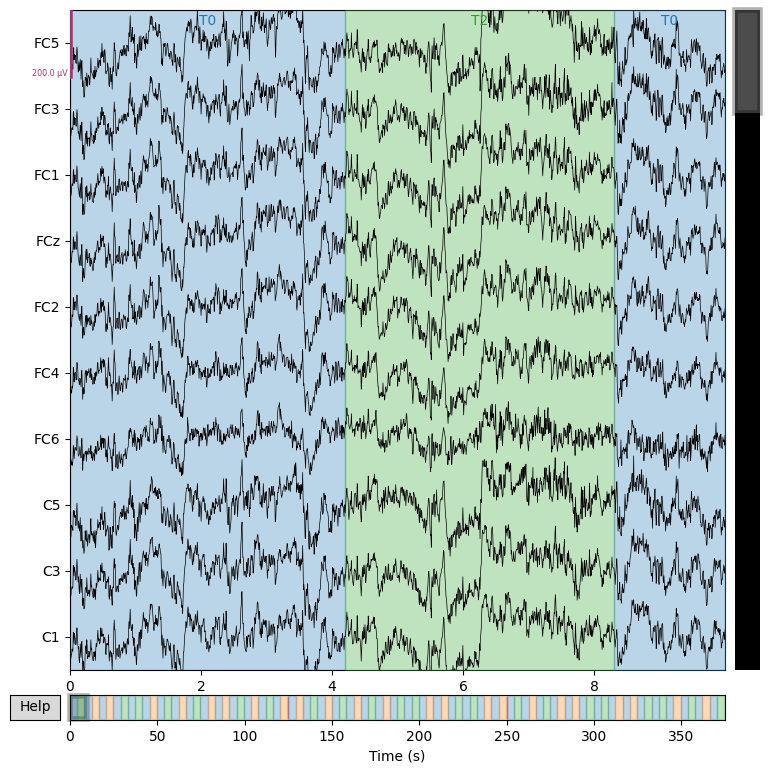

In [6]:
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)
raw.plot(n_channels = 10, duration = 10, scalings = dict(eeg=100e-6))

In [7]:
raw.filter(8.,30.,fir_design="firwin",skip_by_annotation="edge")

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

In [8]:
events, event_id = mne.events_from_annotations(raw)
print(event_id)
picks = mne.pick_types(raw.info, eeg= True, exclude = "bads")
tmin, tmax = 1.0,4.0
epochs = mne.Epochs(
    raw, events, event_id = dict(left =2, right = 3),
    tmin= tmin, tmax=tmax,picks=picks,
    baseline=None, preload = True
)
print(epochs)

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
<Epochs | 45 events (all good), 1 – 4 s (baseline off), ~10.6 MiB, data loaded,
 'left': 23
 'right': 22>


In [9]:
import numpy as np
X_epochs = epochs.get_data()
X = np.log(np.var(X_epochs,axis =2))
y = epochs.events[:,-1]
print(X.shape,y.shape)

(45, 64) (45,)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)
accuracy = knn.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")

Test accuracy: 0.44


In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X, y, cv = 5 )

print(scores)
print(f"Mean CV accuracy: {scores.mean():.2f}(+/-{scores.std():.2f})")

[0.11111111 0.55555556 0.55555556 0.33333333 0.33333333]
Mean CV accuracy: 0.38(+/-0.17)


In [12]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, ShuffleSplit

csp_clf = Pipeline([
    ("CSP", CSP(n_components=6, reg=None, log=True, norm_trace=False)),
    ("KNN", KNeighborsClassifier(n_neighbors=5))
])

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
csp_scores = cross_val_score(csp_clf, X_epochs, y, cv=cv)  # X_epochs from Cell 6, before you took log-variance
print(csp_scores)
print(f"Subject 1 — Mean CV accuracy with CSP: {csp_scores.mean():.2f} (+/- {csp_scores.std():.2f})")

[0.66666667 0.55555556 0.66666667 0.77777778 0.77777778]
Subject 1 — Mean CV accuracy with CSP: 0.69 (+/- 0.08)


In [13]:
def load_subject_data(subject_id, runs=[4, 8, 12]):
    files = eegbci.load_data(subject_id, runs)
    raws = [read_raw_edf(f, preload=True, verbose=False) for f in files]
    raw = concatenate_raws(raws)
    eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage("standard_1005"))
    raw.filter(8., 30., fir_design="firwin", skip_by_annotation="edge", verbose=False)

    events, _ = mne.events_from_annotations(raw, verbose=False)
    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    epochs = mne.Epochs(
        raw, events, event_id=dict(left=2, right=3),
        tmin=1.0, tmax=4.0, picks=picks, baseline=None,
        preload=True, verbose=False
    )
    return epochs.get_data(), epochs.events[:, -1]  # (n_epochs, 64, n_times), labels

all_X_epochs, all_y = [], []
for sub in range(1, 11):
    try:
        X_sub, y_sub = load_subject_data(sub)
        all_X_epochs.append(X_sub)
        all_y.append(y_sub)
        print(f"Subject {sub}: {X_sub.shape[0]} epochs")
    except Exception as e:
        print(f"Subject {sub} failed: {e}")

X_epochs_all = np.concatenate(all_X_epochs, axis=0)
y_all = np.concatenate(all_y)
print(X_epochs_all.shape, y_all.shape)

Subject 1: 45 epochs


Subject 2: 45 epochs


Subject 3: 45 epochs


Subject 4: 45 epochs


Subject 5: 45 epochs


Subject 6: 45 epochs


Subject 7: 45 epochs


Subject 8: 45 epochs


Subject 9: 45 epochs


Subject 10: 45 epochs
(450, 64, 481) (450,)


In [14]:
def load_subject_features(subject_id, runs=[4, 8, 12]):
    files = eegbci.load_data(subject_id, runs)
    raws = [read_raw_edf(f, preload=True, verbose=False) for f in files]
    raw = concatenate_raws(raws)
    eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage("standard_1005"))
    raw.filter(8., 30., fir_design="firwin", skip_by_annotation="edge", verbose=False)

    events, _ = mne.events_from_annotations(raw, verbose=False)
    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    epochs = mne.Epochs(
        raw, events, event_id=dict(left=2, right=3),
        tmin=1.0, tmax=4.0, picks=picks, baseline=None,
        preload=True, verbose=False
    )
    X_sub = np.log(np.var(epochs.get_data(), axis=2))
    y_sub = epochs.events[:, -1]
    return X_sub, y_sub

all_X, all_y = [], []
for sub in range(1, 11):  # subjects 1–10
    try:
        X_sub, y_sub = load_subject_features(sub)
        all_X.append(X_sub)
        all_y.append(y_sub)
        print(f"Subject {sub}: {X_sub.shape[0]} epochs")
    except Exception as e:
        print(f"Subject {sub} failed: {e}")

X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)
print(X_all.shape, y_all.shape)

Subject 1: 45 epochs
Subject 2: 45 epochs
Subject 3: 45 epochs
Subject 4: 45 epochs
Subject 5: 45 epochs
Subject 6: 45 epochs
Subject 7: 45 epochs
Subject 8: 45 epochs
Subject 9: 45 epochs
Subject 10: 45 epochs
(450, 64) (450,)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)

print(f"Test accuracy: {accuracy:.2f}")

Test accuracy: 0.48


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X_all, y_all, cv=5)
print(scores)
print(f"Mean CV accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")

[0.48888889 0.52222222 0.47777778 0.53333333 0.52222222]
Mean CV accuracy: 0.51 (+/- 0.02)


In [17]:
csp_scores_all = cross_val_score(csp_clf, X_epochs_all, y_all, cv=cv)
print(csp_scores_all)
print(f"Pooled (10 subjects) — Mean CV accuracy with CSP: {csp_scores_all.mean():.2f} (+/- {csp_scores_all.std():.2f})")

[0.57777778 0.48888889 0.4        0.44444444 0.52222222]
Pooled (10 subjects) — Mean CV accuracy with CSP: 0.49 (+/- 0.06)


In [18]:
subject_accuracies = []
for i, sub in enumerate(range(1, 11)):
    scores = cross_val_score(csp_clf, all_X_epochs[i], all_y[i], cv=cv)
    subject_accuracies.append(scores.mean())
    print(f"Subject {sub}: {scores.mean():.2f}")

subject_accuracies = np.array(subject_accuracies)
print(f"\nAverage per-subject CSP accuracy: {subject_accuracies.mean():.2f} (+/- {subject_accuracies.std():.2f})")

Subject 1: 0.69
Subject 2: 0.80
Subject 3: 0.47
Subject 4: 0.44
Subject 5: 0.44
Subject 6: 0.56
Subject 7: 0.96
Subject 8: 0.33
Subject 9: 0.40
Subject 10: 0.44

Average per-subject CSP accuracy: 0.55 (+/- 0.19)
